# Lecture 1 — Signals, frequencies and sampling

We will build a signal, find its frequency ingredients, and discover why too few samples can give a misleading answer. **Class route:** investigations 1–6. **Independent practice:** 7–8. Investigation 9 is optional.

Run the short examples from top to bottom. Change one setting, run again, and describe what you see. Restore the starting settings before moving on. The last investigation asks you to put the ideas together yourself.

[Open the lecture slides](../presentations/lecture-1.html). Slide links are optional; all data needed here are supplied locally.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp
from pathlib import Path

plt.rcParams.update({'figure.figsize': (9, 3), 'axes.grid': True})


## Investigation 1 — What does each knob change?

In the lecture, a sine wave was a repeating motion. Start by counting cycles in the plot. One hertz means one cycle per second. Run this example before changing anything.

**Lecture connection:** [slides 2–5](../presentations/lecture-1.html#slide-2).


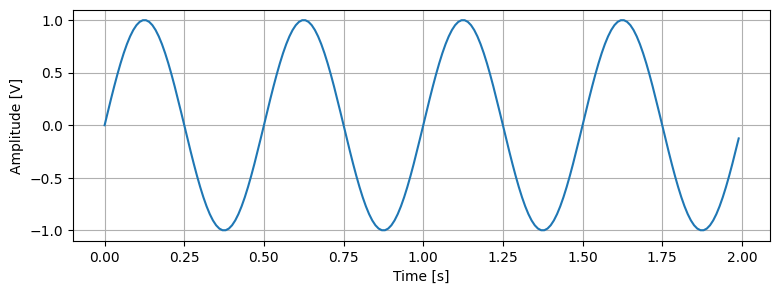

In [3]:
sampling_rate = 100
duration = 2
time = np.arange(sampling_rate * duration) / sampling_rate
amplitude = 1
frequency = 2
phase = 0
signal_values = amplitude * np.sin(2*np.pi*frequency*time + phase)

plt.plot(time, signal_values)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [V]')
plt.show()


**Change one thing at a time in the cell above.**

1. Change amplitude from 1 to 2. What happens to the height? Restore it to 1.
2. Change frequency from 2 to 4. Count cycles over one second. Restore it to 2.
3. Change phase from 0 to np.pi/2. Does the number of cycles change?

A 2 Hz oscillation takes 1/2 second per cycle. The factor 2π converts cycles into radians, which is what NumPy's sine expects.
Thus sin(9*time) means 9 radians per second: about 1.43 Hz, with a period of about 0.698 s.


### Your turn

Make a new plot of a 3 Hz sine of amplitude 0.5 V over 2 s. Check the height and count the cycles.


In [4]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Investigation 2 — What does the instrument actually record?

The smooth curve is the signal we would like to know. The dots are the measurements we keep. Start with just two samples per second for a 1 Hz sine.

**Lecture connection:** [slides 4;9–10;15–17](../presentations/lecture-1.html#slide-4).


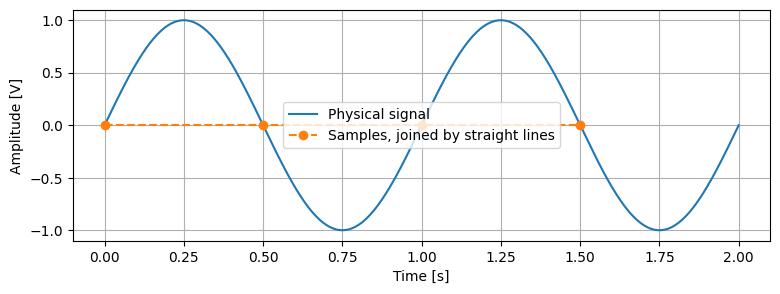

In [5]:
sampling_rate = 2
phase = 0
sample_times = np.arange(2 * sampling_rate) / sampling_rate
samples = np.sin(2*np.pi*sample_times + phase)
smooth_time = np.linspace(0, 2, 1000)

plt.plot(smooth_time, np.sin(2*np.pi*smooth_time + phase), label='Physical signal')
plt.plot(sample_times, samples, 'o--', label='Samples, joined by straight lines')
plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]')
plt.legend(); plt.show()


### Your turn

Rerun the example at sampling rates 3, 4 and 20 Hz. Explain what the connecting line does and does not tell you.

Then return to 2 Hz and change only phase to np.pi/2. Why did the original samples almost vanish? For a signal with unknown phase, should you aim exactly at two samples per cycle?

Finally, use the cell below to generate and plot the 4 Hz sampling case yourself.


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


A line through the dots is a drawing rule. It does not add measurements. For reliable sampling of a band-limited signal, use a rate **above twice its highest frequency**, with an appropriate filter before acquisition.


## Investigation 3 — Find the ingredients of a complicated curve

Now add a slow oscillation and a fast one. First inspect the time plot; then use a spectrum to separate the ingredients.

**Lecture connection:** [slides 6–7;11–12](../presentations/lecture-1.html#slide-6).


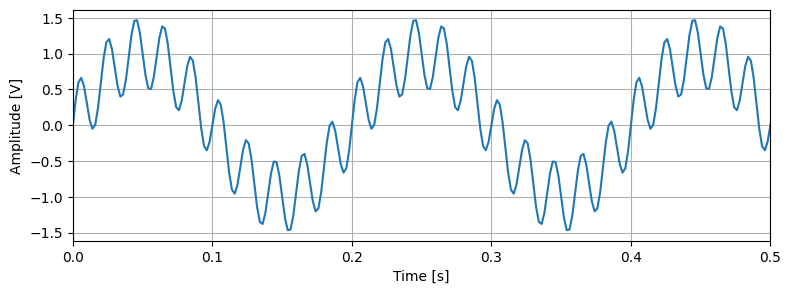

In [13]:
sampling_rate = 500
time = np.arange(1000)/sampling_rate
slow_wave = np.sin(2*np.pi*5*time)
fast_wave = .5*np.sin(2*np.pi*50*time)
mixture = slow_wave + fast_wave

plt.plot(time, mixture)
plt.xlim(0, .5)
plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]'); plt.show()


The periodogram below uses the Fourier transform to estimate how the signal power is distributed across frequency. The first returned array gives the horizontal axis in Hz. A peak identifies a frequency ingredient. We will study the vertical units in Lecture 2.


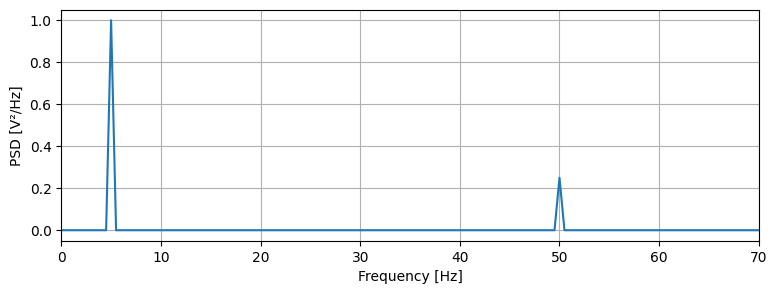

In [15]:
frequencies, power_density = sp.periodogram(mixture, fs=sampling_rate)
plt.plot(frequencies, power_density)
plt.xlim(0, 70)
plt.xlabel('Frequency [Hz]'); plt.ylabel('PSD [V²/Hz]'); plt.show()


### Your turn

Change the fast wave from 50 to 30 Hz, regenerate the mixture, and plot its spectrum. Predict which peak moves. Then double only its amplitude: what happens to its power?


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Investigation 4 — Remove an ingredient and rebuild the signal

The FFT keeps both the size and the timing of frequency ingredients. Keeping this information lets us reconstruct the samples with an inverse FFT. Run the reconstruction first. A real signal produces matching positive and negative frequency partners.

**Lecture connection:** [slides 11–13](../presentations/lecture-1.html#slide-11).


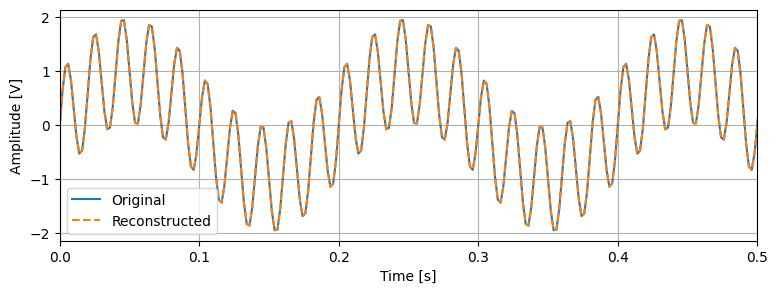

In [20]:
sampling_rate = 500
time = np.arange(1000)/sampling_rate
mixture = np.sin(2*np.pi*5*time) + np.sin(2*np.pi*50*time)
coefficients = np.fft.fft(mixture)
frequencies = np.fft.fftfreq(len(mixture), d=1/sampling_rate)
reconstructed = np.fft.ifft(coefficients).real

plt.plot(time, mixture, label='Original')
plt.plot(time, reconstructed, '--', label='Reconstructed')
plt.xlim(0, .5); plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]')
plt.legend(); plt.show()


To remove the 5 Hz ingredient, remove coefficients whose frequency is between −20 and +20 Hz. Keep both partners of the 50 Hz ingredient. The following three lines make that change; inspect the reconstructed waveform.


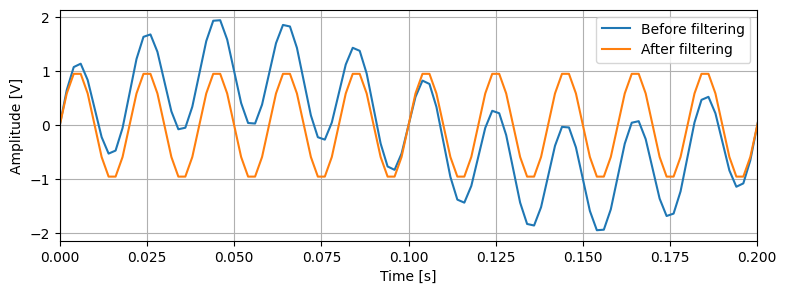

In [23]:
filtered_coefficients = coefficients.copy()
filtered_coefficients[np.abs(frequencies) < 20] = 0
filtered_signal = np.fft.ifft(filtered_coefficients).real

plt.plot(time, mixture, label='Before filtering')
plt.plot(time, filtered_signal, label='After filtering')
plt.xlim(0, .2); plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]')
plt.legend(); plt.show()


### Your turn

Reverse the experiment: keep only frequencies below 20 Hz in magnitude. Which wave should remain? Plot it and check by counting cycles.


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


Keep the complex coefficients for reconstruction; taking their absolute values discards timing information. This simple filter works particularly cleanly for these whole-cycle tones. A sharp cutoff can cause ringing with other signals.


## Investigation 5 — How can sine waves make a different shape?

Start with a 5 Hz sine. Add a smaller 15 Hz sine, then a smaller 25 Hz sine. These are the third and fifth harmonics: three and five times the starting frequency.

**Lecture connection:** [slides 8–10](../presentations/lecture-1.html#slide-8).


**Exam connection:** January 2026: distinguish waveform frequency content from sampling choices.


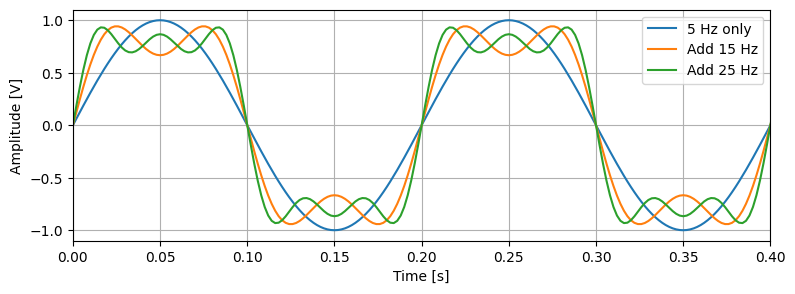

In [28]:
sampling_rate = 500
time = np.arange(500)/sampling_rate
fundamental = np.sin(2*np.pi*5*time)
third_harmonic = np.sin(2*np.pi*15*time)/3
fifth_harmonic = np.sin(2*np.pi*25*time)/5

plt.plot(time, fundamental, label='5 Hz only')
plt.plot(time, fundamental + third_harmonic, label='Add 15 Hz')
plt.plot(time, fundamental + third_harmonic + fifth_harmonic, label='Add 25 Hz')
plt.xlim(0, .4); plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]')
plt.legend(); plt.show()


The shape is becoming flatter at the top and steeper at the sides. The extra frequencies describe those details. These sums have not been rescaled to unit height. The square-wave demonstration in the slides lets you add more harmonics.


### Your turn

Plot a spectrum of the three-wave sum and identify all three ingredients. What sampling rate is needed to retain them?

A 20 Hz waveform is represented using harmonics up to nine times its fundamental. Calculate the highest frequency and a safe sampling condition. Explain why considering only 20 Hz would fail.


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Investigation 6 — Why does 153 Hz appear at 47 Hz?

This is the aliasing problem from the exams. The physical signal is fixed. Change the sampling rate, regenerate the samples, and inspect the peak.

**Lecture connection:** [slides 9–10;15–17](../presentations/lecture-1.html#slide-9).


**Exam connection:** 9 January 2025, signal generation → PSD → alias prediction.


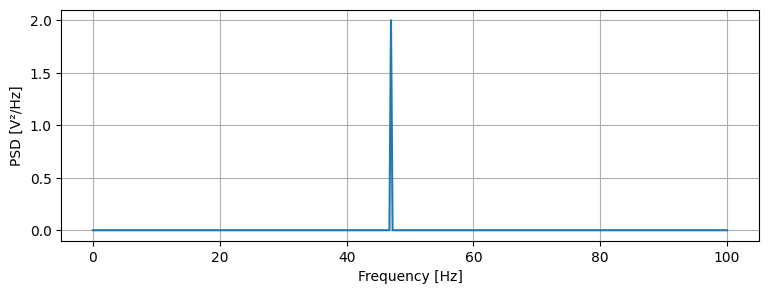

Observed peak: 47.0 Hz


In [32]:
frequency = 153
sampling_rate = 200
duration = 4
time = np.arange(duration*sampling_rate)/sampling_rate
samples = np.sin(2*np.pi*frequency*time)
frequencies, power_density = sp.periodogram(samples, fs=sampling_rate)
peak_frequency = frequencies[np.argmax(power_density)]

plt.plot(frequencies, power_density)
plt.xlabel('Frequency [Hz]'); plt.ylabel('PSD [V²/Hz]'); plt.show()
print('Observed peak:', peak_frequency, 'Hz')


At 200 samples/s, the observable band ends at 100 Hz. The 153 Hz oscillation folds back to **200 − 153 = 47 Hz**. At lower rates, folding can happen repeatedly. Subtract the nearest whole multiple of the sampling rate, then take the absolute value.


### Your turn

Try sampling rates 100, 200 and 400 Hz, predicting the peak before each run. Explain why changing only fs in the periodogram call would merely relabel existing samples.

Next generate the original 433, 144 and 36 Hz mixture at 150 Hz. Predict its three observed peaks and verify them. What rate would preserve all three physical frequencies?


<details><summary>A small hint, if needed</summary>

For the 433 Hz component at 150 samples/s, the nearest whole multiple is 450 Hz. Their difference is 17 Hz. A peak index is a position in an array; use the frequency array to convert it to Hz.

</details>


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Investigation 7 — Build your own aliasing investigation

You have now used the same signal-generation steps several times. A function lets you reuse those steps. Run this small example, then build the rest of the investigation.

**Lecture connection:** [slides 9;15–17;20](../presentations/lecture-1.html#slide-9).


**Exam connection:** 10 January 2024 and 9 January 2025, observed frequency versus sampling rate.


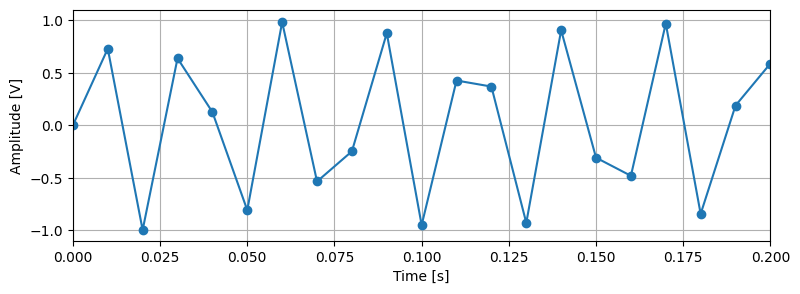

In [37]:
def make_sine(frequency, sampling_rate, duration=4, amplitude=1):
    time = np.arange(int(duration*sampling_rate))/sampling_rate
    samples = amplitude*np.sin(2*np.pi*frequency*time)
    return time, samples

time, samples = make_sine(frequency=37, sampling_rate=100)
plt.plot(time, samples, 'o-')
plt.xlim(0, .2); plt.xlabel('Time [s]'); plt.ylabel('Amplitude [V]'); plt.show()


### Your turn

For a 37 Hz signal, investigate **20 sampling rates from 10 to 200 Hz**, in steps of 10 Hz.

For each rate, generate a fresh signal, calculate its PSD, and store the frequency of its largest peak. Plot observed frequency against sampling rate. Explain the shape and mark the rate above which the true frequency is retained.

Check three points by hand. Then repeat for the 153 Hz exam example using rates up to 500 Hz.


<details><summary>A small hint, if needed</summary>

Start with one rate and check the result. Then place those steps in a loop. Append each measured peak to a list. You can use np.argmax to find the strongest peak in this single-tone exercise.

</details>


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Investigation 8 — Explain a repair, as you would in an exam

The following code is deliberately wrong. Read it without executing it. The intended physical frequencies are 15, 50 and 130 Hz; the acquisition rate is fixed at 100 Hz.

**Lecture connection:** [slides 18;20](../presentations/lecture-1.html#slide-18).


**Exam connection:** 14 and 23 January 2026, repair an analysis and explain the violated concepts.


```python
from scipy import signal
sampling_rate = 100
time = np.arange(0, 0.1, sampling_rate)
signal = np.sin(15*time) + np.sin(50*time) + np.sin(130*time)
frequencies, density = signal.welch(signal, fs=1, scaling='spectrum')
plt.plot(frequencies, density)
plt.ylabel('PSD [V²/Hz]')
```


### Your turn

Write a working analysis. Keep the sampling rate and physical frequencies fixed; you may use a longer record. For each correction, explain its visible or numerical consequence.

Predict what happens to 130 Hz and to the zero-phase 50 Hz sine. Would a successful plot mean you had recovered all three original oscillations?


In [ ]:
# Write your analysis here. Use the examples above as a starting point.


**What did you observe, and how do you explain it?**

*Write a few sentences here. Refer to a plotted feature or a measured value.*


## Optional investigation 9 — Why does abs() keep the peak visible?

Slide 12 says that a frequency can appear in the real or imaginary part, depending on the starting phase. Slide 19 writes those two comparisons as one complex response. Test the idea with one 5 Hz tone: change its phase while keeping its amplitude, frequency and recording duration fixed.

**Lecture connection:** [slides 12;19](../presentations/lecture-1.html#slide-12).


Real part: 100.0
Imaginary part: -0.0
Magnitude: 100.0


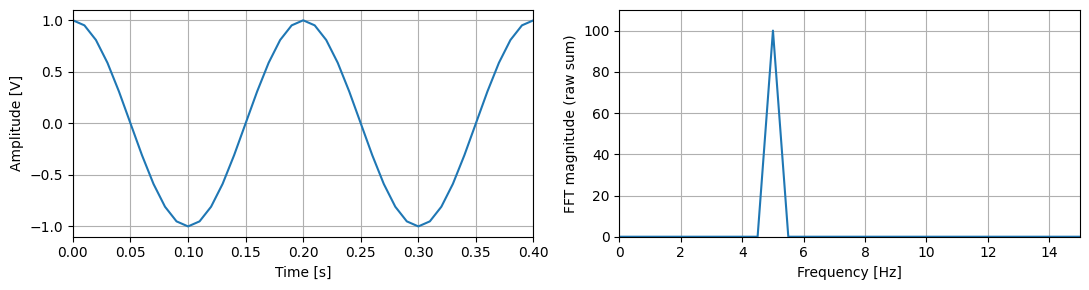

In [43]:
sampling_rate = 100
time = np.arange(200) / sampling_rate
frequency = 5
phase = 0  # Try -np.pi/2, then -np.pi/4.
samples = np.cos(2*np.pi*frequency*time + phase)

coefficients = np.fft.fft(samples)
frequencies = np.fft.fftfreq(len(samples), d=1/sampling_rate)
positive = frequencies >= 0
frequency_bin = np.argmin(np.abs(frequencies - frequency))
coefficient = coefficients[frequency_bin]
print('Real part:', round(coefficient.real, 2))
print('Imaginary part:', round(coefficient.imag, 2))
print('Magnitude:', round(abs(coefficient), 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(time, samples)
axes[0].set(xlim=(0, 0.4), ylim=(-1.1, 1.1),
            xlabel='Time [s]', ylabel='Amplitude [V]')
axes[1].plot(frequencies[positive], np.abs(coefficients[positive]))
axes[1].set(xlim=(0, 15), ylim=(0, 110),
            xlabel='Frequency [Hz]', ylabel='FFT magnitude (raw sum)')
plt.tight_layout(); plt.show()


**Change one thing at a time.**

1. With `phase = 0`, the waveform starts as a cosine. Note the real part, imaginary part and magnitude.
2. Set `phase = -np.pi/2`: it now starts as a sine. Before running, predict which of the two parts will carry the response. Does the 5 Hz peak move or change height?
3. Set `phase = -np.pi/4`. Both parts now contribute. Does their combined magnitude change?

The `frequency_bin` line selects the coefficient at 5 Hz. We recorded ten complete cycles so this comparison isolates phase. The printed magnitude of 100 is a raw FFT sum over 200 samples; the wave's amplitude is still 1 V.

**Connect this to the lecture:** why could plotting only the real part make you miss a tone? What does `abs()` keep, and what information would you lose if you threw away the original complex coefficients?


**Your explanation:**

*Refer to the waveform, the 5 Hz peak and the printed real and imaginary parts.*


## Before you finish

Can you explain what each plot tells you, why you chose the sampling rate and analysis settings, and what the analysis cannot recover? Label axes with quantities and units. Restart the kernel and run all cells to check that your work is reproducible.
